In [1]:
import math
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from tensorflow import data as tf_data

SEED = 42
keras.utils.set_random_seed(SEED)

In [3]:
BATCH_SIZE = 128
BUFFER_SIZE = BATCH_SIZE * 2
AUTO = tf_data.AUTOTUNE
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
IMAGE_SIZE = 48
DIMENSIONS = 256
SE_RATIO = 8
TRUNK_DEPTH = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 50

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
(x_train, y_train), (x_val, y_val) = (
    (x_train[:40000], y_train[:40000]),
    (x_train[40000:], y_train[40000:]),
)
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

train_ds = tf_data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf_data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf_data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTO)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 203s 1us/step
Training samples: 40000
Validation samples: 10000
Testing samples: 10000


In [5]:
def get_preprocessing():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name="preprocessing",
    )
    return model


def get_train_augmentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(INPUT_SHAPE[0] + 20, INPUT_SHAPE[0] + 20),
            layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
            layers.RandomFlip("horizontal"),
        ],
        name="train_data_augmentation",
    )
    return model

In [6]:
def build_convolutional_stem(dimensions):

    config = {
        "kernel_size": (3, 3),
        "strides": (2, 2),
        "activation": ops.gelu,
        "padding": "same",
    }

    convolutional_stem = keras.Sequential(
        [
            layers.Conv2D(filters=dimensions // 2, **config),
            layers.Conv2D(filters=dimensions, **config),
        ],
        name="convolutional_stem",
    )

    return convolutional_stem

In [7]:

class SqueezeExcite(layers.Layer):


    def __init__(self, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

    def build(self, input_shape):
        filters = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D(keepdims=True)
        self.reduction = layers.Dense(
            units=filters // self.ratio,
            activation="relu",
            use_bias=False,
        )
        self.excite = layers.Dense(units=filters, activation="sigmoid", use_bias=False)
        self.multiply = layers.Multiply()

    def call(self, x):
        shortcut = x
        x = self.squeeze(x)
        x = self.reduction(x)
        x = self.excite(x)
        x = self.multiply([shortcut, x])
        return x


class Trunk(layers.Layer):


    def __init__(self, depth, dimensions, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.dimensions = dimensions
        self.depth = depth

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "ratio": self.ratio,
                "dimensions": self.dimensions,
                "depth": self.depth,
            }
        )
        return config

    def build(self, input_shape):
        config = {
            "filters": self.dimensions,
            "activation": ops.gelu,
            "padding": "same",
        }

        trunk_block = [
            layers.LayerNormalization(epsilon=1e-6),
            layers.Conv2D(kernel_size=(1, 1), **config),
            layers.Conv2D(kernel_size=(3, 3), **config),
            SqueezeExcite(ratio=self.ratio),
            layers.Conv2D(kernel_size=(1, 1), filters=self.dimensions, padding="same"),
        ]

        self.trunk_blocks = [keras.Sequential(trunk_block) for _ in range(self.depth)]
        self.add = layers.Add()
        self.flatten_spatial = layers.Reshape((-1, self.dimensions))

    def call(self, x):
        # Remember the input.
        shortcut = x
        for trunk_block in self.trunk_blocks:
            output = trunk_block(x)
            shortcut = self.add([output, shortcut])
            x = shortcut
        # Flatten the patches.
        x = self.flatten_spatial(x)
        return x

In [8]:

class AttentionPooling(layers.Layer):


    def __init__(self, dimensions, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.dimensions = dimensions
        self.num_classes = num_classes
        self.cls = keras.Variable(ops.zeros((1, 1, dimensions)))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "dimensions": self.dimensions,
                "num_classes": self.num_classes,
                "cls": self.cls.numpy(),
            }
        )
        return config

    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=1,
            key_dim=self.dimensions,
            dropout=0.2,
        )
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential(
            [
                layers.Dense(units=self.dimensions, activation=ops.gelu),
                layers.Dropout(0.2),
                layers.Dense(units=self.dimensions, activation=ops.gelu),
            ]
        )
        self.dense = layers.Dense(units=self.num_classes)
        self.flatten = layers.Flatten()

    def call(self, x):
        batch_size = ops.shape(x)[0]

        class_token = ops.repeat(self.cls, repeats=batch_size, axis=0)

        x = ops.concatenate([class_token, x], axis=1)

        x = self.layer_norm1(x)
        x, viz_weights = self.attention(
            query=x[:, 0:1], key=x, value=x, return_attention_scores=True
        )
        class_token = class_token + x
        class_token = self.layer_norm2(class_token)
        class_token = self.flatten(class_token)
        class_token = self.layer_norm3(class_token)
        class_token = class_token + self.mlp(class_token)

        logits = self.dense(class_token)
        return logits, ops.squeeze(viz_weights)[..., 1:]

In [9]:
class PatchConvNet(keras.Model):
    def __init__(
        self,
        stem,
        trunk,
        attention_pooling,
        preprocessing_model,
        train_augmentation_model,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.stem = stem
        self.trunk = trunk
        self.attention_pooling = attention_pooling
        self.train_augmentation_model = train_augmentation_model
        self.preprocessing_model = preprocessing_model

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "stem": self.stem,
                "trunk": self.trunk,
                "attention_pooling": self.attention_pooling,
                "train_augmentation_model": self.train_augmentation_model,
                "preprocessing_model": self.preprocessing_model,
            }
        )
        return config

    def _calculate_loss(self, inputs, test=False):
        images, labels = inputs

        if test:
            augmented_images = self.preprocessing_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, _ = self.attention_pooling(x)

        total_loss = self.compiled_loss(labels, logits)
        return total_loss, logits

    def train_step(self, inputs):
        with tf.GradientTape() as tape:
            total_loss, logits = self._calculate_loss(inputs)

        train_vars = [
            self.stem.trainable_variables,
            self.trunk.trainable_variables,
            self.attention_pooling.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        trainable_variable_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                trainable_variable_list.append((g, v))
        self.optimizer.apply_gradients(trainable_variable_list)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, inputs):
        total_loss, logits = self._calculate_loss(inputs, test=True)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def call(self, images):

        augmented_images = self.preprocessing_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, viz_weights = self.attention_pooling(x)
        return logits, viz_weights

In [10]:
test_images, test_labels = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 4:
            test_augmented_images = self.model.preprocessing_model(test_images)

            test_x = self.model.stem(test_augmented_images)

            test_x = self.model.trunk(test_x)

            _, test_viz_weights = self.model.attention_pooling(test_x)

            num_patches = ops.shape(test_viz_weights)[-1]
            height = width = int(math.sqrt(num_patches))
            test_viz_weights = layers.Reshape((height, width))(test_viz_weights)

            index = np.random.randint(low=0, high=ops.shape(test_augmented_images)[0])
            selected_image = test_augmented_images[index]
            selected_weight = test_viz_weights[index]

            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
            ax[0].imshow(selected_image)
            ax[0].set_title(f"Original: {epoch:03d}")
            ax[0].axis("off")
            img = ax[1].imshow(selected_image)
            ax[1].imshow(
                selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent()
            )
            ax[1].set_title(f"Attended: {epoch:03d}")
            ax[1].axis("off")
            plt.axis("off")
            plt.show()
            plt.close()

In [11]:

class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
        self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps
    ):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = np.pi

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total_steps must be larger or equal to warmup_steps.")
        cos_annealed_lr = ops.cos(
            self.pi
            * (ops.cast(step, "float32") - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)
        )
        learning_rate = 0.5 * self.learning_rate_base * (1 + cos_annealed_lr)
        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError(
                    "Learning_rate_base must be larger or equal to "
                    "warmup_learning_rate."
                )
            slope = (
                self.learning_rate_base - self.warmup_learning_rate
            ) / self.warmup_steps
            warmup_rate = slope * ops.cast(step, "float32") + self.warmup_learning_rate
            learning_rate = ops.where(
                step < self.warmup_steps, warmup_rate, learning_rate
            )
        return ops.where(
            step > self.total_steps,
            0.0,
            learning_rate,
        )


total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    learning_rate_base=LEARNING_RATE,
    total_steps=total_steps,
    warmup_learning_rate=0.0,
    warmup_steps=warmup_steps,
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:667: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:642: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 112ms/step - accuracy: 0.1831 - top-5-accuracy: 0.6632 - loss: 0.1262 - val_loss: 0.1175
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.3886 - top-5-accuracy: 0.8933 - loss: 0.0710 - val_loss: 0.0700
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.4815 - top-5-accuracy: 0.9295 - loss: 0.0222 - val_loss: 0.0325
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5558 - top-5-accuracy: 0.9485 - loss: 0.0038 - val_loss: 0.0468
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6058 - top-5-accuracy: 0.9603 - loss: -0.0082

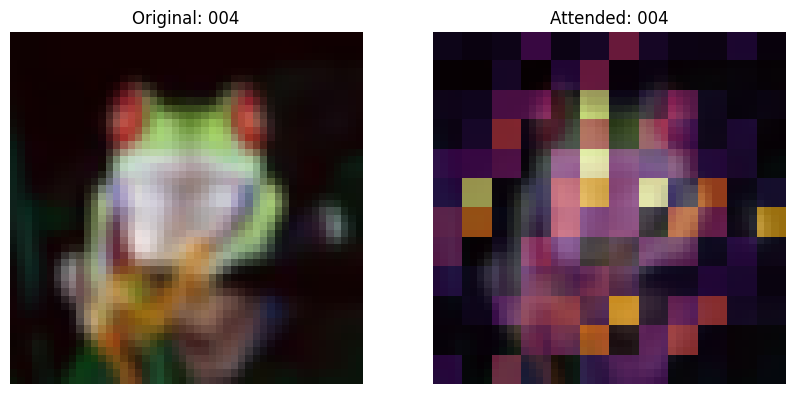

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.6058 - top-5-accuracy: 0.9604 - loss: -0.0082 - val_loss: -0.0145
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.6383 - top-5-accuracy: 0.9681 - loss: -0.0461 - val_loss: -0.0347
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.6785 - top-5-accuracy: 0.9739 - loss: -0.0480 - val_loss: -0.0292
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.7053 - top-5-accuracy: 0.9796 - loss: -0.0655 - val_loss: -0.0160
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7424 - top-5-accuracy: 0.9844 - loss: -0.0846 - val_loss: -0.1605
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7609 - top-5-accuracy: 0.9851 - loss: -0.0928

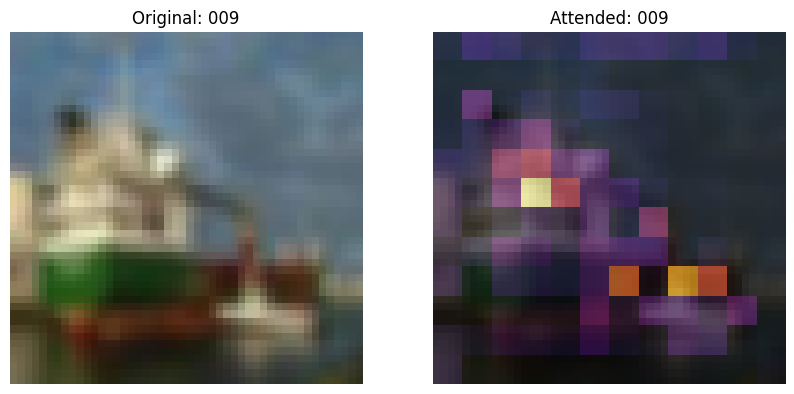

313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.7610 - top-5-accuracy: 0.9851 - loss: -0.0929 - val_loss: -0.1350
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.7860 - top-5-accuracy: 0.9885 - loss: -0.1006 - val_loss: -0.1408
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.8010 - top-5-accuracy: 0.9899 - loss: -0.1102 - val_loss: -0.1641
Epoch 13/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 110ms/step - accuracy: 0.8125 - top-5-accuracy: 0.9910 - loss: -0.1516 - val_loss: -0.1623
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.8217 - top-5-accuracy: 0.9914 - loss: -0.1327 - val_loss: -0.1712
Epoch 15/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8262 - top-5-accuracy: 0.9930 - loss: -0.1544

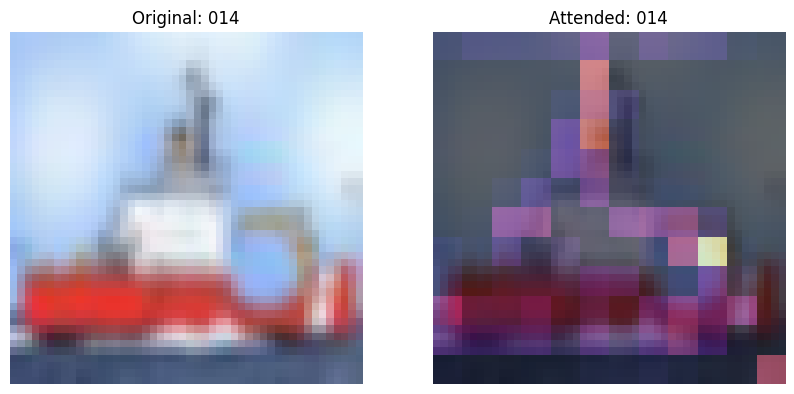

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8262 - top-5-accuracy: 0.9929 - loss: -0.1544 - val_loss: -0.1703
Epoch 16/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8407 - top-5-accuracy: 0.9938 - loss: -0.1536 - val_loss: -0.2192
Epoch 17/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.8484 - top-5-accuracy: 0.9945 - loss: -0.1619 - val_loss: -0.1399
Epoch 18/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.8590 - top-5-accuracy: 0.9957 - loss: -0.1596 - val_loss: -0.1604
Epoch 19/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.8657 - top-5-accuracy: 0.9954 - loss: -0.1914 - val_loss: -0.1599
Epoch 20/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8696 - top-5-accuracy: 0.9962 - loss: -0.1791

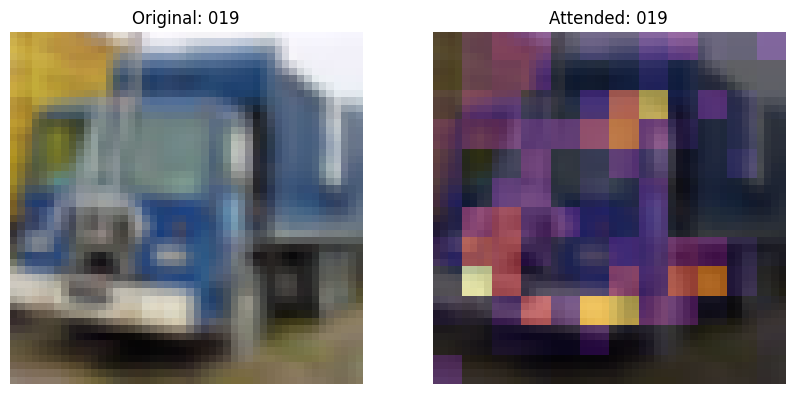

313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8694 - top-5-accuracy: 0.9962 - loss: -0.1791 - val_loss: -0.1648
Epoch 21/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - accuracy: 0.8761 - top-5-accuracy: 0.9963 - loss: -0.2196 - val_loss: -0.1547
Epoch 22/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8800 - top-5-accuracy: 0.9963 - loss: -0.1933 - val_loss: -0.2120
Epoch 23/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.8925 - top-5-accuracy: 0.9972 - loss: -0.2332 - val_loss: -0.1567
Epoch 24/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8987 - top-5-accuracy: 0.9973 - loss: -0.2175 - val_loss: -0.1961
Epoch 25/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9076 - top-5-accuracy: 0.9982 - loss: -0.2257

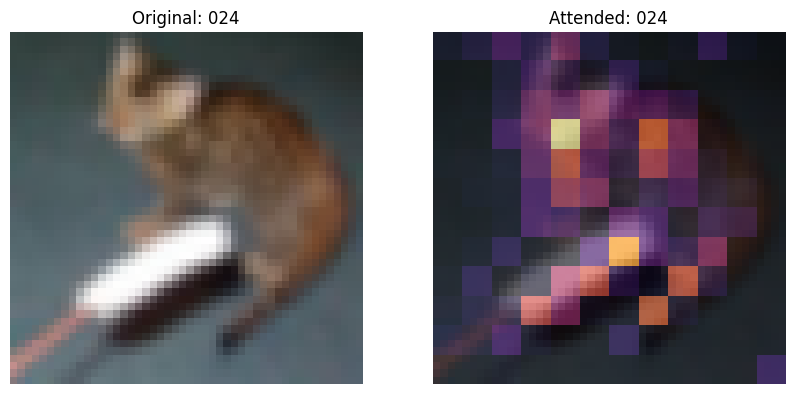

313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9074 - top-5-accuracy: 0.9981 - loss: -0.2257 - val_loss: -0.2600
Epoch 26/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 110ms/step - accuracy: 0.9137 - top-5-accuracy: 0.9986 - loss: -0.2422 - val_loss: -0.2173
Epoch 27/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9185 - top-5-accuracy: 0.9983 - loss: -0.2478 - val_loss: -0.1765
Epoch 28/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.9210 - top-5-accuracy: 0.9991 - loss: -0.2347 - val_loss: -0.1946
Epoch 29/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9278 - top-5-accuracy: 0.9993 - loss: -0.2213 - val_loss: -0.2812
Epoch 30/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9322 - top-5-accuracy: 0.9995 - loss: -0.2386

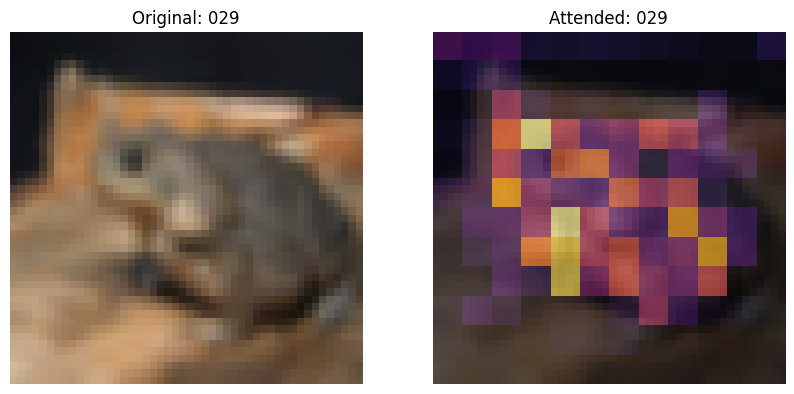

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.9319 - top-5-accuracy: 0.9995 - loss: -0.2386 - val_loss: -0.2729
Epoch 31/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.9418 - top-5-accuracy: 0.9995 - loss: -0.2562 - val_loss: -0.2318
Epoch 32/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9457 - top-5-accuracy: 0.9992 - loss: -0.2428 - val_loss: -0.2587
Epoch 33/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9507 - top-5-accuracy: 0.9995 - loss: -0.2358 - val_loss: -0.2708
Epoch 34/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.9547 - top-5-accuracy: 0.9998 - loss: -0.2751 - val_loss: -0.2610
Epoch 35/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9594 - top-5-accuracy: 0.9997 - loss: -0.2530

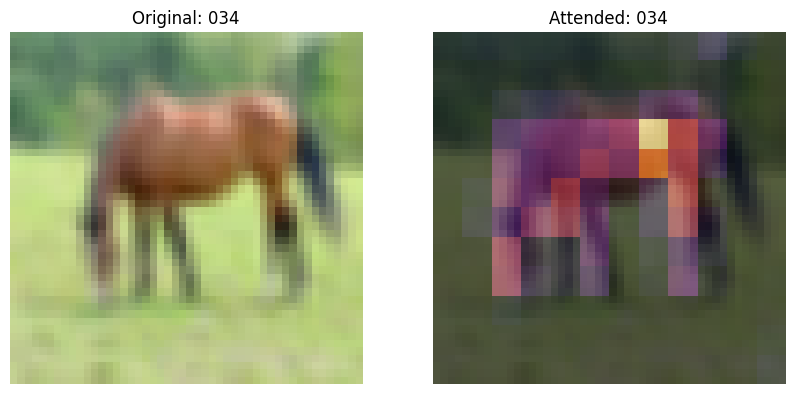

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9590 - top-5-accuracy: 0.9996 - loss: -0.2531 - val_loss: -0.2145
Epoch 36/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9649 - top-5-accuracy: 0.9999 - loss: -0.2320 - val_loss: -0.2757
Epoch 37/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9701 - top-5-accuracy: 0.9999 - loss: -0.2246 - val_loss: -0.2772
Epoch 38/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9721 - top-5-accuracy: 0.9999 - loss: -0.2413 - val_loss: -0.2480
Epoch 39/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.9781 - top-5-accuracy: 0.9999 - loss: -0.2271 - val_loss: -0.2300
Epoch 40/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9814 - top-5-accuracy: 0.9999 - loss: -0.2044

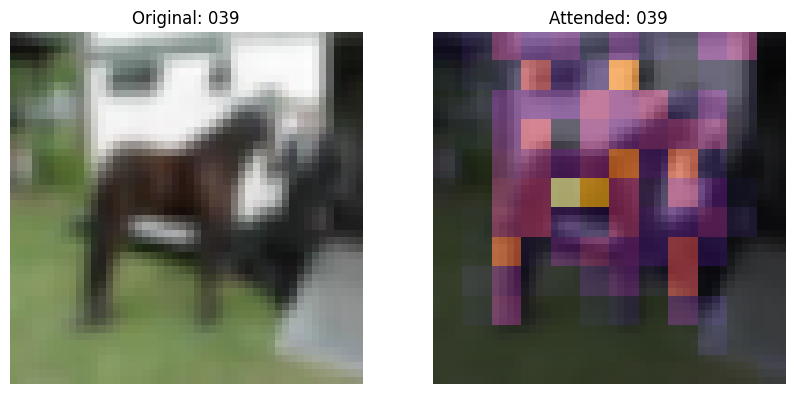

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9810 - top-5-accuracy: 0.9999 - loss: -0.2044 - val_loss: -0.3078
Epoch 41/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.9825 - top-5-accuracy: 0.9999 - loss: -0.2069 - val_loss: -0.2248
Epoch 42/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.9856 - top-5-accuracy: 1.0000 - loss: -0.2026 - val_loss: -0.2021
Epoch 43/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.9870 - top-5-accuracy: 1.0000 - loss: -0.1622 - val_loss: -0.2020
Epoch 44/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.9898 - top-5-accuracy: 0.9999 - loss: -0.1617 - val_loss: -0.1331
Epoch 45/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9912 - top-5-accuracy: 1.0000 - loss: -0.1442

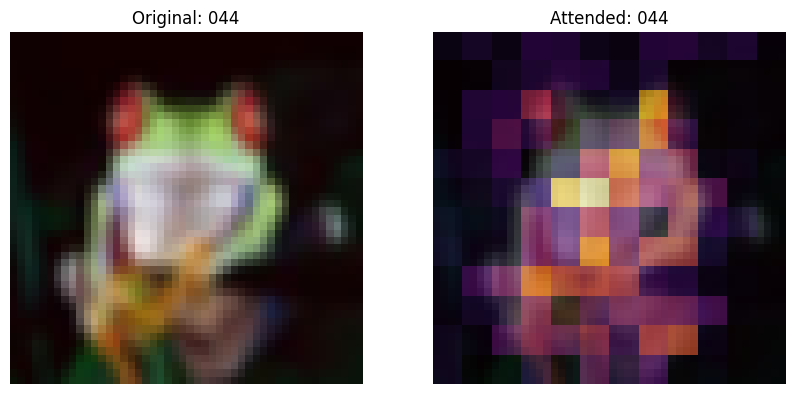

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.9908 - top-5-accuracy: 1.0000 - loss: -0.1442 - val_loss: -0.1420
Epoch 46/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.9921 - top-5-accuracy: 0.9999 - loss: -0.1224 - val_loss: -0.1047
Epoch 47/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9934 - top-5-accuracy: 1.0000 - loss: -0.0991 - val_loss: -0.0989
Epoch 48/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - accuracy: 0.9934 - top-5-accuracy: 1.0000 - loss: -0.1022 - val_loss: -0.1060
Epoch 49/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9940 - top-5-accuracy: 1.0000 - loss: -0.0997 - val_loss: -0.0957
Epoch 50/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9942 - top-5-accuracy: 1.0000 - loss: -0.0983

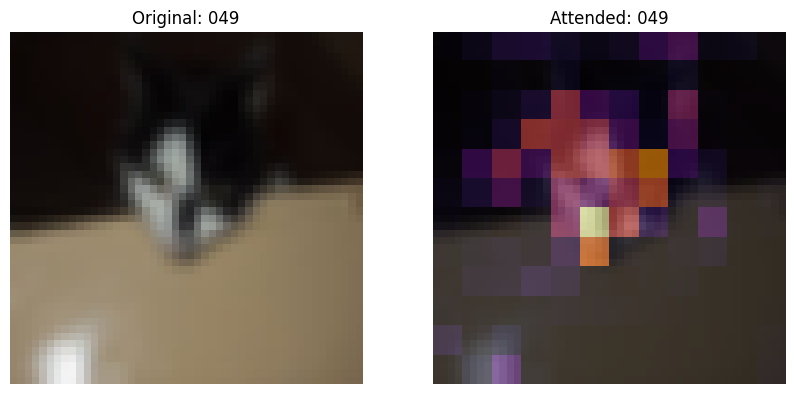

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9938 - top-5-accuracy: 1.0000 - loss: -0.0983 - val_loss: -0.0972
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8593 - top-5-accuracy: 0.9921 - loss: -0.1009


ValueError: not enough values to unpack (expected 3, got 2)

In [12]:
train_augmentation_model = get_train_augmentation_model()
preprocessing_model = get_preprocessing()
conv_stem = build_convolutional_stem(dimensions=DIMENSIONS)
conv_trunk = Trunk(depth=TRUNK_DEPTH, dimensions=DIMENSIONS, ratio=SE_RATIO)
attention_pooling = AttentionPooling(dimensions=DIMENSIONS, num_classes=NUM_CLASSES)

patch_conv_net = PatchConvNet(
    stem=conv_stem,
    trunk=conv_trunk,
    attention_pooling=attention_pooling,
    train_augmentation_model=train_augmentation_model,
    preprocessing_model=preprocessing_model,
)


train_callbacks = [TrainMonitor(epoch_interval=5)]

optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

patch_conv_net.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)
history = patch_conv_net.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)


loss, acc_top1, acc_top5 = patch_conv_net.evaluate(test_ds)
print(f"Loss: {loss:0.2f}")
print(f"Top 1 test accuracy: {acc_top1*100:0.2f}%")
print(f"Top 5 test accuracy: {acc_top5*100:0.2f}%")

In [72]:

def plot_attention(image):
    image = ops.image.resize(image, (224, 224))
    image = image[np.newaxis, ...]
    test_augmented_images = patch_conv_net.preprocessing_model(image)

    test_x = patch_conv_net.stem(test_augmented_images)

    test_x = patch_conv_net.trunk(test_x)

    _, test_viz_weights = patch_conv_net.attention_pooling(test_x)
    test_viz_weights = test_viz_weights[np.newaxis, ...]

    num_patches = ops.shape(test_viz_weights)[-1]
    height = width = int(math.sqrt(num_patches))
    test_viz_weights = layers.Reshape((height, width))(test_viz_weights)
    selected_image = test_augmented_images[0]
    selected_weight = test_viz_weights[0]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].imshow(selected_image)
    ax[0].set_title(f"Original")
    ax[0].axis("off")
    img = ax[1].imshow(selected_image)
    ax[1].imshow(selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent())
    ax[1].set_title(f"Attention")
    ax[1].axis("off")
    plt.axis("off")
    plt.show()
    plt.close()


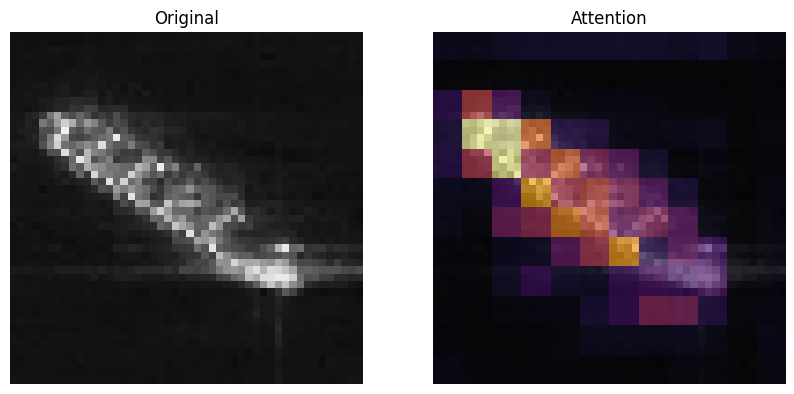

In [73]:
import numpy as np
import os
image_path = "/content/cargo2.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

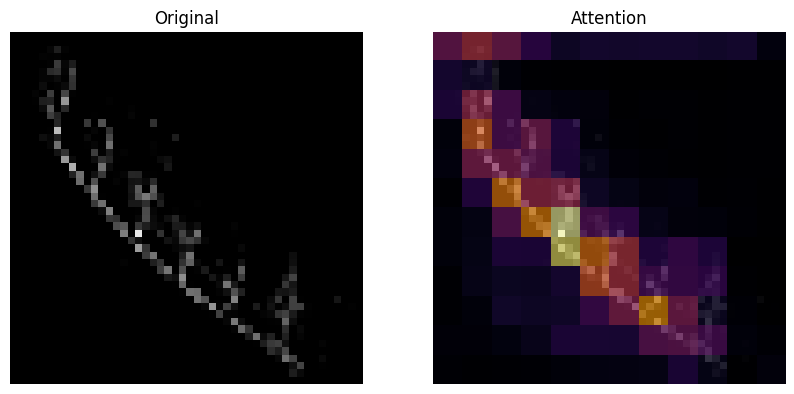

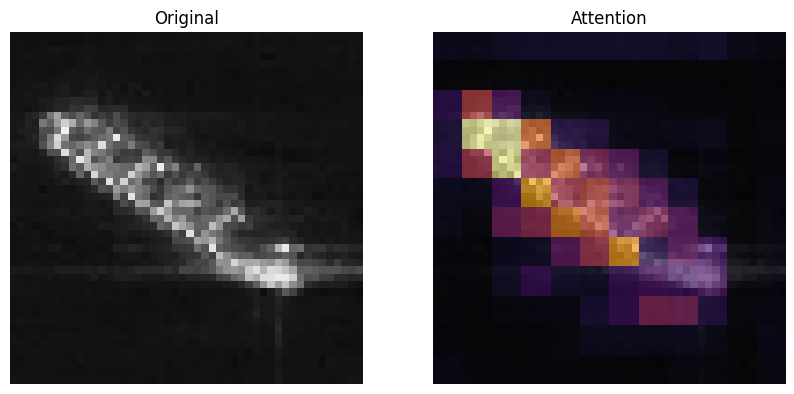

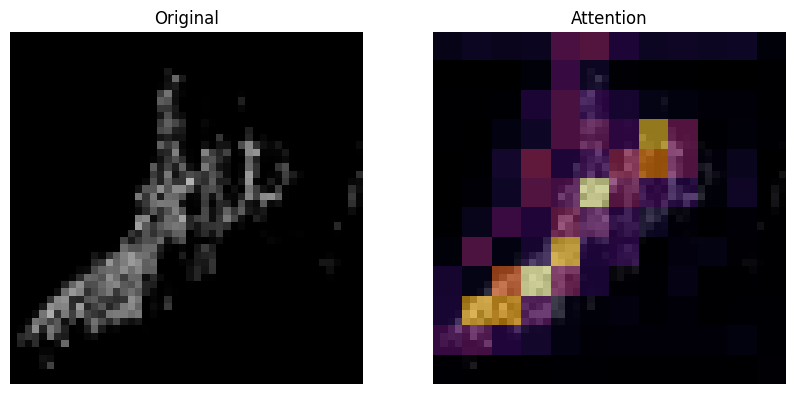

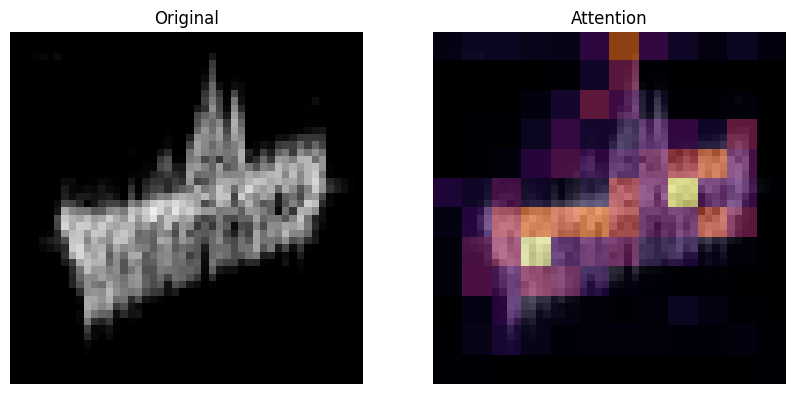

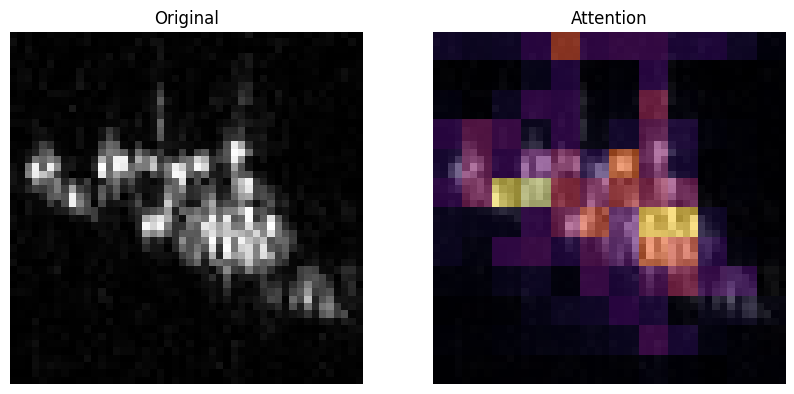

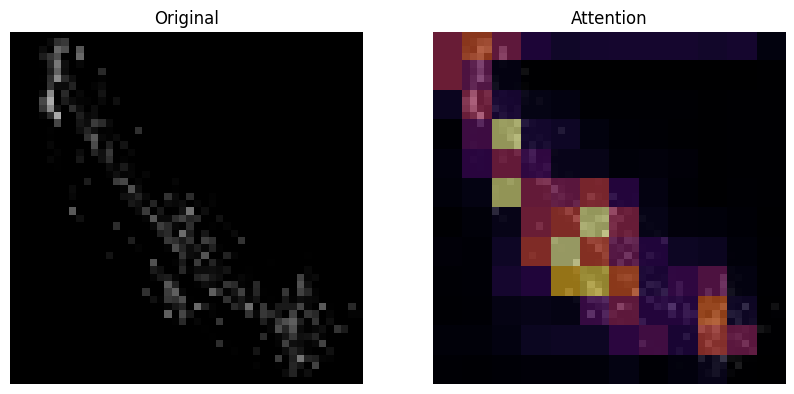

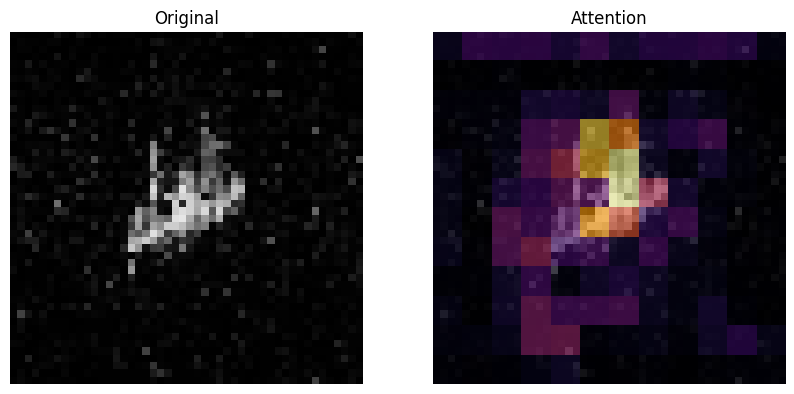

In [78]:
import numpy as np
import os
image_path = "/content/cargo.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/cargo2.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/frigate.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/mainclasstarget.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/markship2.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/otanker.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/sailer.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)
